# Fungsi Preprocessing pada data raw

## 1. Mengimpor Library dan module yang dibutuhkan

WAJIB ADA KARENA INI NOTEBOOK

In [1]:
# LIBRARY
import sys
sys.path.append('..')
# Menambahkan path ke folder parent (satu level di atas)
# Tujuannya agar bisa import module dari folder src/
# (karena notebook ada di folder notebooks/)

# LIBRARY DAN MODULE DARI FILE LAIN
import pandas as pd
from sklearn.model_selection import train_test_split
from src import bersihkan_teks_total,bersihkan_teks_minimal,encode_label_series
from src import simpan_objek  

## 2. Logika Code

### 2.1 Load dataset

In [2]:
import pandas as pd

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../data/raw/datasetUMPOHoax.csv")


In [3]:
df.head()

,topik,keyword,tweet,gambar,url,label
0,NaN,NaN,"hati hati dengan chemtrail, asap yg dikeluarka...",NaN,https://twitter.com/yudhistiroagung/status/887...,1
1,coklat,coklat dapat menaikkan mood,Coklat terbukti bisa menaikkan mood kak hehe,NaN,https://twitter.com/ExCommunicad/status/124896...,1
2,Tidur malam,Efek tidur larut malam,Efek tidur larut malam kek gini -___- jam segi...,NaN,https://twitter.com/a_away/status/461301980925...,1
3,NaN,NaN,kurang ajar trnyata kopi luak white koffie men...,NaN,https://twitter.com/sayyidalydrus17/status/321...,1
4,tangan berkeringat,tangan berkeringat tanda jantung lemah,Telapak Tangan Berkeringat Tanda Lemah Jantung...,NaN,https://twitter.com/newskabarberita/status/521...,0



### 2.2 Melihat Distribusi Fakta dan Hoax

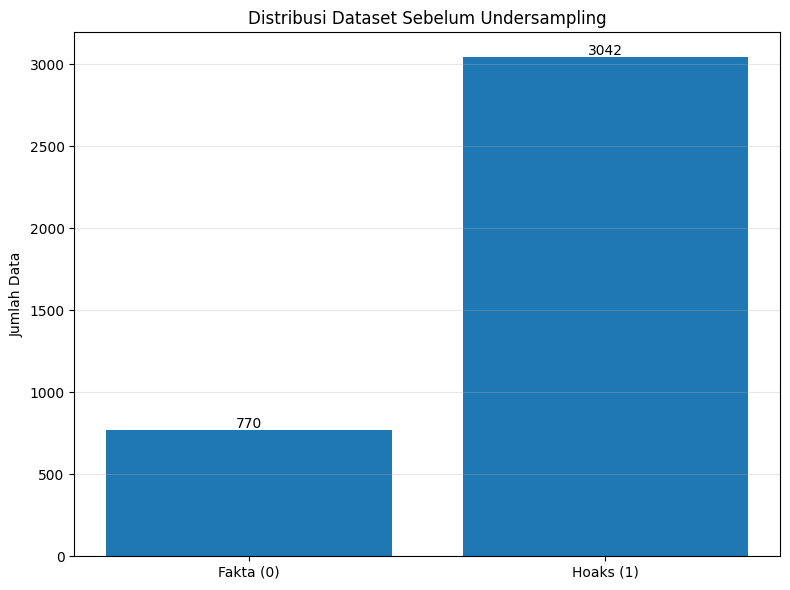

In [4]:
import matplotlib.pyplot as plt  # Import library matplotlib untuk membuat visualisasi/grafik

# Menghitung jumlah data per label (0=Fakta, 1=Hoaks) dan diurutkan berdasarkan index
before_counts = df['label'].value_counts().sort_index()

# Membuat label sumbu X untuk grafik
labels = ['Fakta (0)', 'Hoaks (1)']

# Membuat figure (kanvas) dengan ukuran 8x6 inci
plt.figure(figsize=(8, 6))

# Membuat bar chart dengan label sebagai sumbu X dan jumlah data sebagai tinggi bar
bars = plt.bar(labels, before_counts.values)

# Menambahkan angka di atas setiap bar agar jumlah data terlihat langsung
for bar in bars:
    y = bar.get_height()  # Mengambil tinggi bar (= jumlah data)
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Posisi X: tepat di tengah bar
        y + 15,                              # Posisi Y: sedikit di atas puncak bar
        f'{int(y)}',                         # Teks yang ditampilkan (angka jumlah data)
        ha='center'                          # Rata tengah secara horizontal
    )

# Menambahkan label pada sumbu Y
plt.ylabel('Jumlah Data')

# Menambahkan judul grafik
plt.title('Distribusi Dataset Sebelum Undersampling')

# Menampilkan garis grid horizontal dengan transparansi 30% agar tidak terlalu mencolok
plt.grid(axis='y', alpha=0.3)

# Menyesuaikan layout agar tidak ada elemen yang terpotong
plt.tight_layout()

# Menampilkan grafik ke layar
plt.show()

### 2.3 Melakukan Undersampling Pada Data

In [5]:
# ============================================================
# 4. UNDERSAMPLING
# ============================================================

# Memisahkan data berdasarkan label:
# df_hoax  → hanya berisi berita hoaks (label = 1)
# df_fakta → hanya berisi berita fakta (label = 0)
df_hoax  = df[df['label'] == 1]
df_fakta = df[df['label'] == 0]

# Menentukan rasio undersampling (90%)
# Artinya jumlah data hoaks akan disesuaikan menjadi 90% dari jumlah data fakta
ratio  = 0.9
n_hoax = int(len(df_fakta) * ratio)  # Menghitung target jumlah data hoaks

# Memastikan jumlah sampel hoaks tidak melebihi data hoaks yang tersedia
n_hoax = min(n_hoax, len(df_hoax))

# Mengambil sampel acak dari data hoaks sebanyak n_hoax
# random_state=42 agar hasil sampling konsisten setiap kali dijalankan
df_hoax_sample = df_hoax.sample(n=n_hoax, random_state=42)

# Menggabungkan data hoaks (yang sudah di-undersample) dengan data fakta
df_balanced = pd.concat([df_hoax_sample, df_fakta])

# Mengacak urutan seluruh data agar tidak terurut berdasarkan label
# frac=1 berarti ambil 100% data, reset_index agar index kembali dari 0
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Menampilkan jumlah data per label setelah proses undersampling
print("\nDistribusi setelah undersampling:")
print(df_balanced['label'].value_counts())


# ============================================================
# 5. VALIDASI
# ============================================================

# Memastikan hanya ada 2 label unik (0 dan 1), tidak ada label lain yang tidak diinginkan
print("\nCek label unik:", df_balanced['label'].unique())

# Menampilkan total jumlah data akhir setelah undersampling
print("Jumlah data akhir:", len(df_balanced))


Distribusi setelah undersampling:
label
0    770
1    693
Name: count, dtype: int64

Cek label unik: [0 1]
Jumlah data akhir: 1463


#### 2.3.1 Melihat hasil undersampling

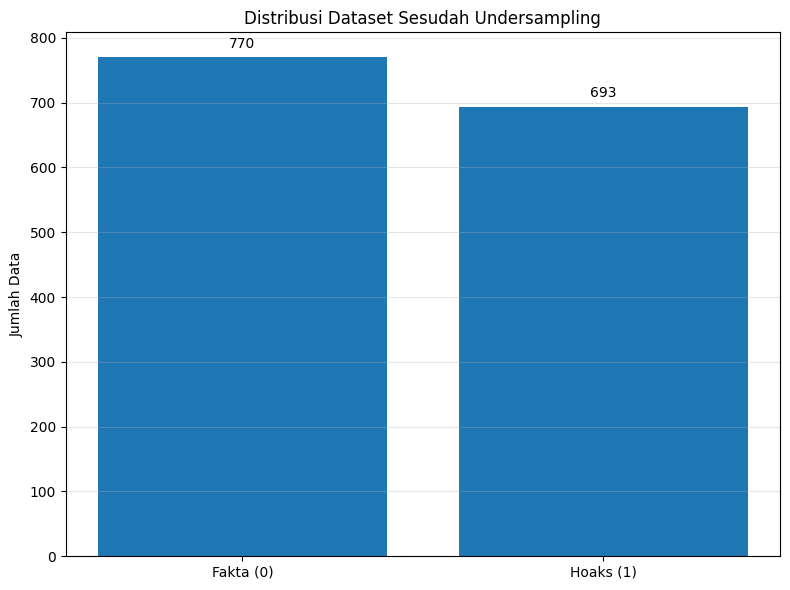

In [6]:
import matplotlib.pyplot as plt

# Distribusi setelah
after_counts = df_balanced['label'].value_counts().sort_index()
labels = ['Fakta (0)', 'Hoaks (1)']

plt.figure(figsize=(8,6))

bars = plt.bar(labels, after_counts.values)

# Tambahin angka di atas bar
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 15,
        f'{int(y)}',
        ha='center'
    )

plt.ylabel('Jumlah Data')
plt.title('Distribusi Dataset Sesudah Undersampling')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4 Split Data (80% training, 20% testing)

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['tweet'],        # Fitur (teks)
    df['label'],        # Target (label hoaks / bukan)
    test_size=0.2,      # 20% data untuk testing
    random_state=42,    # Seed agar hasil split selalu sama (reproducible)
    stratify=df['label'] # Menjaga proporsi label tetap seimbang di train & test
)



In [11]:
# =========================
# SIMPAN HASIL SPLIT
# =========================

import pandas as pd

train_df = pd.DataFrame({
    "tweet": X_train_raw,
    "label": y_train
})

test_df = pd.DataFrame({
    "tweet": X_test_raw,
    "label": y_test
})

train_df.to_csv("data_train.csv", index=False)
test_df.to_csv("data_test.csv", index=False)

### 2.5 Proses Pembersihan teks 

In [9]:
X_train_clean = X_train_raw.apply(bersihkan_teks_total)
# Membersihkan data training menggunakan preprocessing lengkap
# apply() → menerapkan fungsi ke setiap baris data teks

# SELANJUTNYA MEMBERSIHKAN DATASET DENGAN 2 TIPE
X_test_clean = X_test_raw.apply(bersihkan_teks_total)  
# Data uji versi bersih (ideal condition)

X_test_noisy = X_test_raw.apply(bersihkan_teks_minimal)  
# Data uji versi noisy (real-world condition)
# Digunakan untuk menguji robustness model

#### 2.5.1 Membuat dictionary dan menyimpan hasil preprocessing

In [10]:
data_mentah = {
    'X_train_clean': X_train_clean,  # Data training yang sudah dibersihkan
    'y_train': y_train,              # Label training

    'X_test_clean': X_test_clean,    # Data test bersih
    'y_test': y_test,                # Label test

    'X_test_noisy': X_test_noisy     # Data test kotor (simulasi dunia nyata)
}

# Menyimpan dictionary ke file .pkl menggunakan pickle
simpan_objek(data_mentah, '../data/processed/data_teks_bersih.pkl')

print("Data teks berhasil dibersihkan dan disimpan!")
# Notifikasi bahwa proses selesai

Data teks berhasil dibersihkan dan disimpan!
